# EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

In [2]:
# --- STYLE CONFIGURATION FOR MEMORY / VISUALIZATION ---
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 8)

## Functions

In [3]:
# Histograms of critical variables
def plot_histograms(df):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    sns.histplot(df['temp_setpoint_leche'], kde=True, ax=axes[0,0]).set_title('Pasteurization Setpoint Distribution (°C)')
    sns.histplot(df['flujo_leche_lh'], kde=True, ax=axes[0,1]).set_title('Milk Flow Distribution (L/h)')
    sns.histplot(df['presion_diferencial_bar'], kde=True, ax=axes[1,0]).set_title('Pressure Distribution (Fouling)')
    sns.histplot(df['consumo_agua_l'], kde=True, ax=axes[1,1]).set_title('Target: Water Consumption (L)')
    plt.tight_layout()
    plt.show()

In [4]:
# Correlation heatmap
def correlation_heatmap(df):
    plt.figure(figsize=(10, 8))
    mask = np.triu(np.ones_like(df.corr(), dtype=bool))
    sns.heatmap(df.corr(), mask=mask, annot=True, cmap='RdBu', fmt=".2f")
    plt.title("IIoT Sensor Correlation Matrix")
    plt.show()

In [5]:
# Visualization of the Fouling Effect (Deposits/Scaling)
def fouling_effect_analysis(df):
    # Relationship between operating hours, pressure, and consumption
    plt.figure(figsize=(12, 6))
    scatter = plt.scatter(df['horas_desde_limpieza'], df['consumo_agua_l'], 
                c=df['presion_diferencial_bar'], cmap='autumn', alpha=0.5)
    plt.colorbar(scatter, label='Differential Pressure (Bar)')
    plt.xlabel('Hours Since Last Cleaning (Accumulated Fouling)')
    plt.ylabel('Total Water Consumption (L)')
    plt.title('Impact of Fouling on Energy Efficiency (Water Consumption)')
    plt.show()

In [6]:
# Relationship between Setpoint and Pasteurization Units (PU)
def setpoint_pu_relationship(df):
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x='temp_setpoint_leche', y='valor_pu_microbiologico')
    plt.axhline(y=15, color='r', linestyle='--', label='Legal Limit (15 PU)')
    plt.yscale('log') # Log scale because PU grows exponentially
    plt.title('Safety Validation: Temperature vs Pasteurization Units')
    plt.legend()
    plt.show()

In [7]:
def security_boxplots(df):
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='indice_seguridad', y='consumo_agua_l', data=df)
    plt.title('Consumption Difference: Safe vs Unsafe Processes')
    plt.xticks([0, 1], ['Unsafe (<15 PU)', 'Safe (>=15 PU)'])
    plt.show()

## Results

In [8]:
data_path = '../../data/processed/milk_dataset.csv'

# 1. Cargar y analizar datos
df = pd.read_csv(data_path)

In [9]:
df['indice_seguridad'].value_counts()

indice_seguridad
1    4823
0     177
Name: count, dtype: int64

### DESCRIPTIVE STATISTICS ###


,count,mean,std,min,25%,50%,75%,max
temp_entrada_leche,5000.0,4.089459,0.493892,2.414161,3.753486,4.086444,4.426203,5.944547
temp_ambiente,5000.0,21.936640,5.792673,12.000233,16.877256,22.000173,26.962017,31.994353
temp_setpoint_leche,5000.0,75.035843,1.722040,72.000289,73.554286,75.057173,76.499866,77.997938
temp_proceso_leche,5000.0,75.033515,1.739313,71.574181,73.535792,75.058340,76.501864,78.693738
temp_agua_servicio,5000.0,85.021270,2.876157,77.831440,82.980466,84.998761,87.121939,92.167810
flujo_leche_lh,5000.0,3746.006526,729.914624,2500.394361,3107.130432,3728.880809,4397.363929,4999.812067
horas_desde_limpieza,5000.0,10.201563,5.742974,0.005049,5.380934,10.289486,15.061296,19.998020
presion_diferencial_bar,5000.0,1.072041,0.248210,0.341003,0.939062,1.142519,1.254829,1.565029
consumo_agua_l,5000.0,24065.575028,5027.816726,12450.679973,19970.427402,23880.025936,27972.178999,36659.452351
valor_pu_microbiologico,5000.0,50.918597,30.892834,10.235928,26.029380,42.773320,69.053127,173.662789


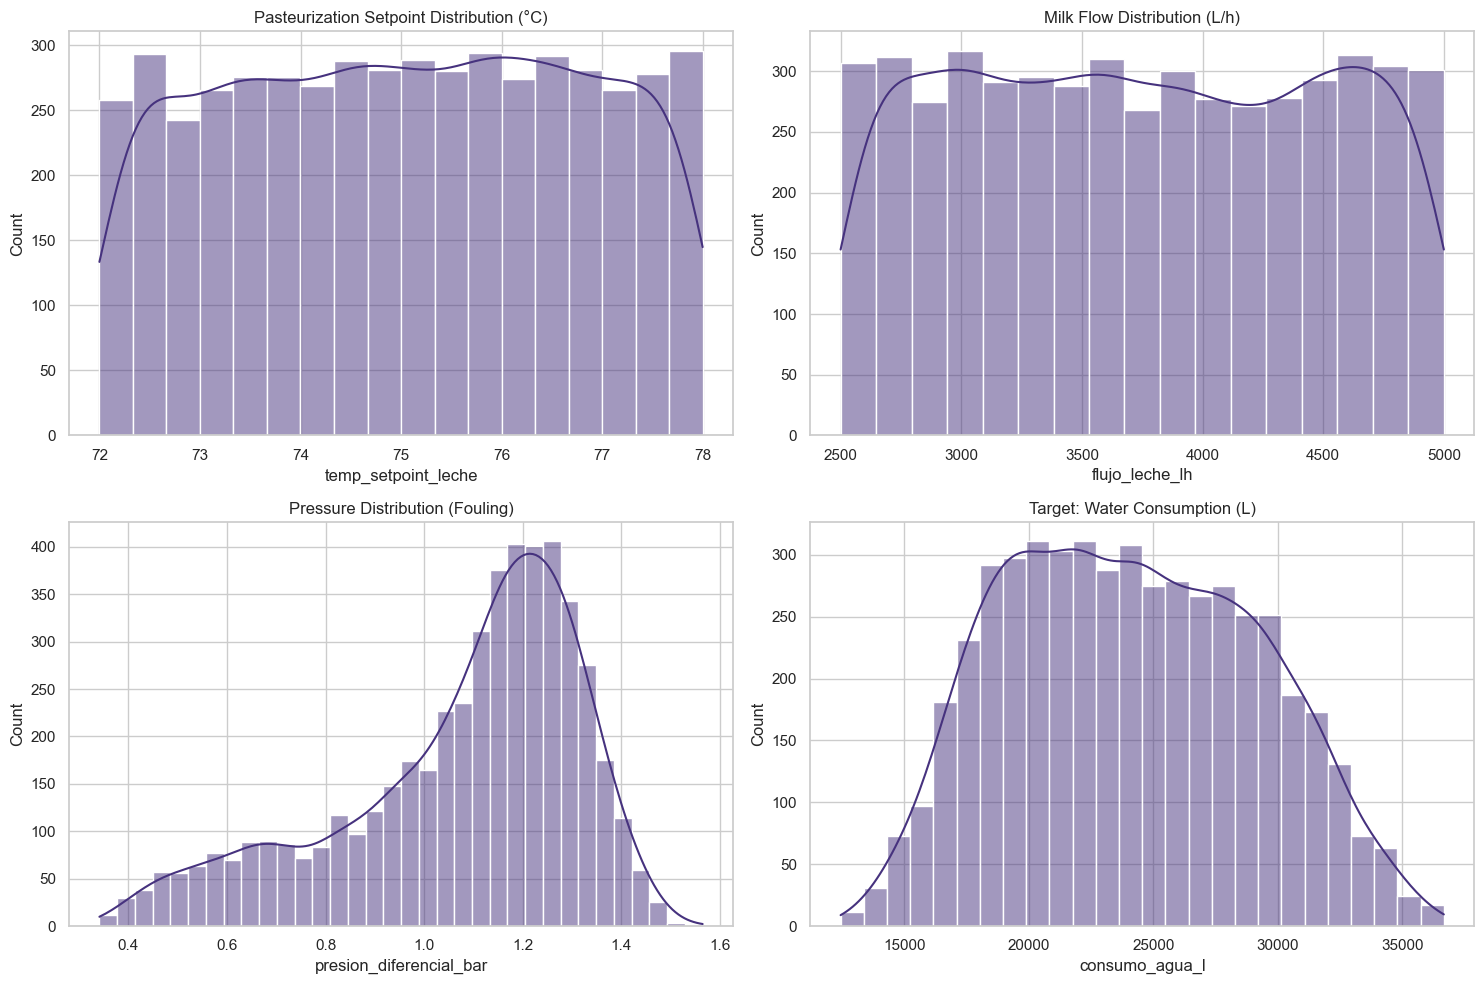

In [10]:
# =============================================================
# SECTION 1: DISTRIBUTION AND DATA INTEGRITY ANALYSIS
# =============================================================
print("### DESCRIPTIVE STATISTICS ###")
display(df.describe().T)
plot_histograms(df)

In [11]:
df['valor_pu_microbiologico'].mean()

np.float64(50.91859712395033)

In [12]:
df['indice_seguridad'].value_counts()

indice_seguridad
1    4823
0     177
Name: count, dtype: int64

# New

Física: El ensuciamiento (presion_diferencial_bar) no solo depende del tiempo (horas_desde_limpieza), sino que la tasa de deposición proteica es exponencial con la temperatura de la leche (temp_proceso_leche). Esta gráfica demuestra que el problema es multivariante.

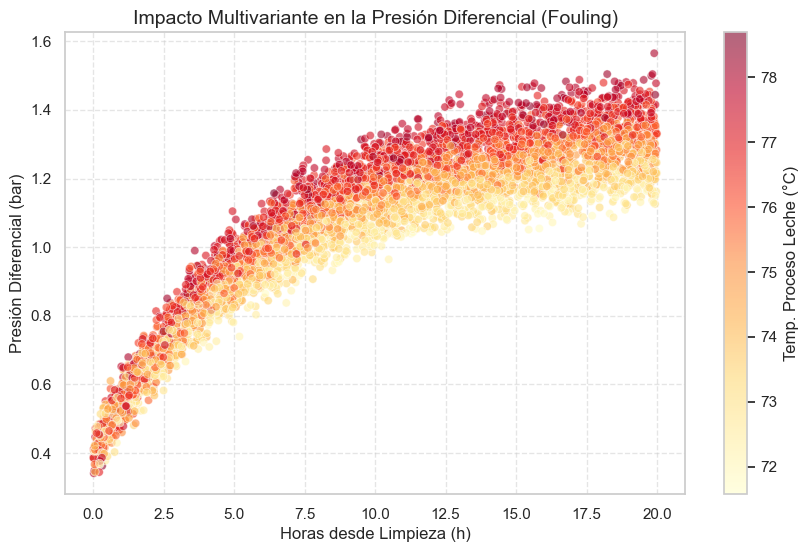

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Gráfica 1: Cinética de Ensuciamiento
plt.figure(figsize=(10, 6))
# Usamos un Scatter plot con colormap para añadir la tercera dimensión (temperatura)
sc = plt.scatter(df['horas_desde_limpieza'], 
                 df['presion_diferencial_bar'], 
                 c=df['temp_proceso_leche'], # Colormap basado en la temperatura real
                 cmap='YlOrRd', # Amarillo a Rojo para calor
                 alpha=0.6, 
                 edgecolor='w', 
                 linewidth=0.5)

plt.colorbar(sc, label='Temp. Proceso Leche (°C)')
plt.title('Impacto Multivariante en la Presión Diferencial (Fouling)', fontsize=14)
plt.xlabel('Horas desde Limpieza (h)', fontsize=12)
plt.ylabel('Presión Diferencial (bar)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


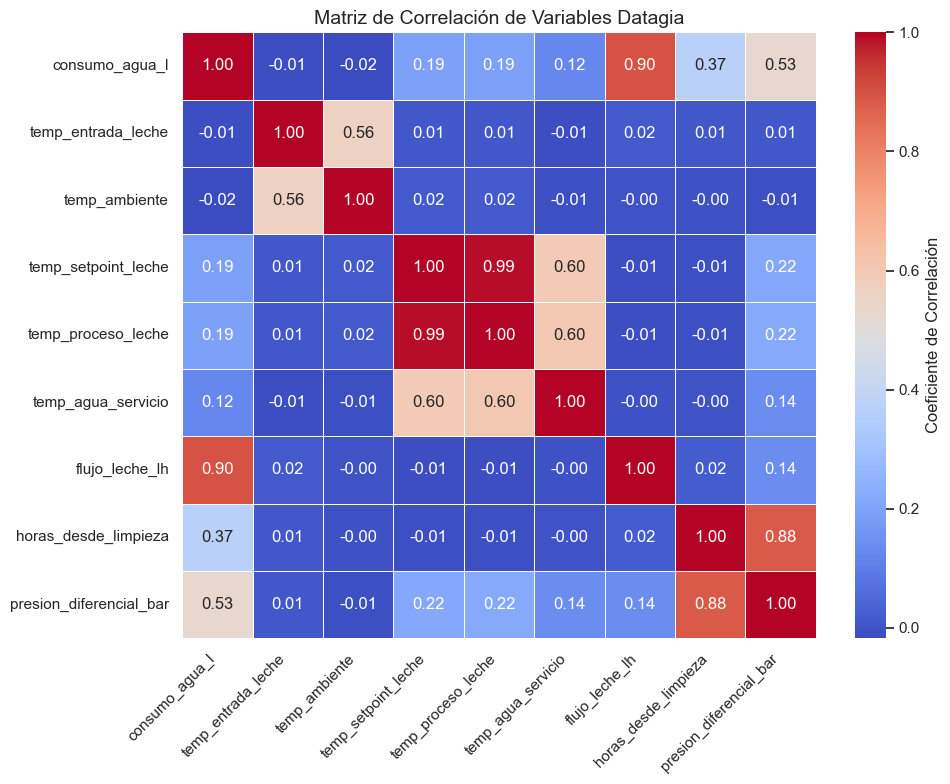

In [14]:
# Gráfica 2: Heatmap de Correlación
plt.figure(figsize=(10, 8))
# Calculamos la correlación de Pearson
corr_matrix = df[['consumo_agua_l', 'temp_entrada_leche', 'temp_ambiente', 'temp_setpoint_leche', 'temp_proceso_leche',
            'temp_agua_servicio', 'flujo_leche_lh', 'horas_desde_limpieza', 'presion_diferencial_bar']].corr()


# Dibujamos el Heatmap
sns.heatmap(corr_matrix, 
            annot=True, # Mostrar los valores
            cmap='coolwarm', # Escala de color de frío a calor
            fmt=".2f", # Dos decimales
            linewidths=.5,
            cbar_kws={'label': 'Coeficiente de Correlación'})

plt.title('Matriz de Correlación de Variables Datagia', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

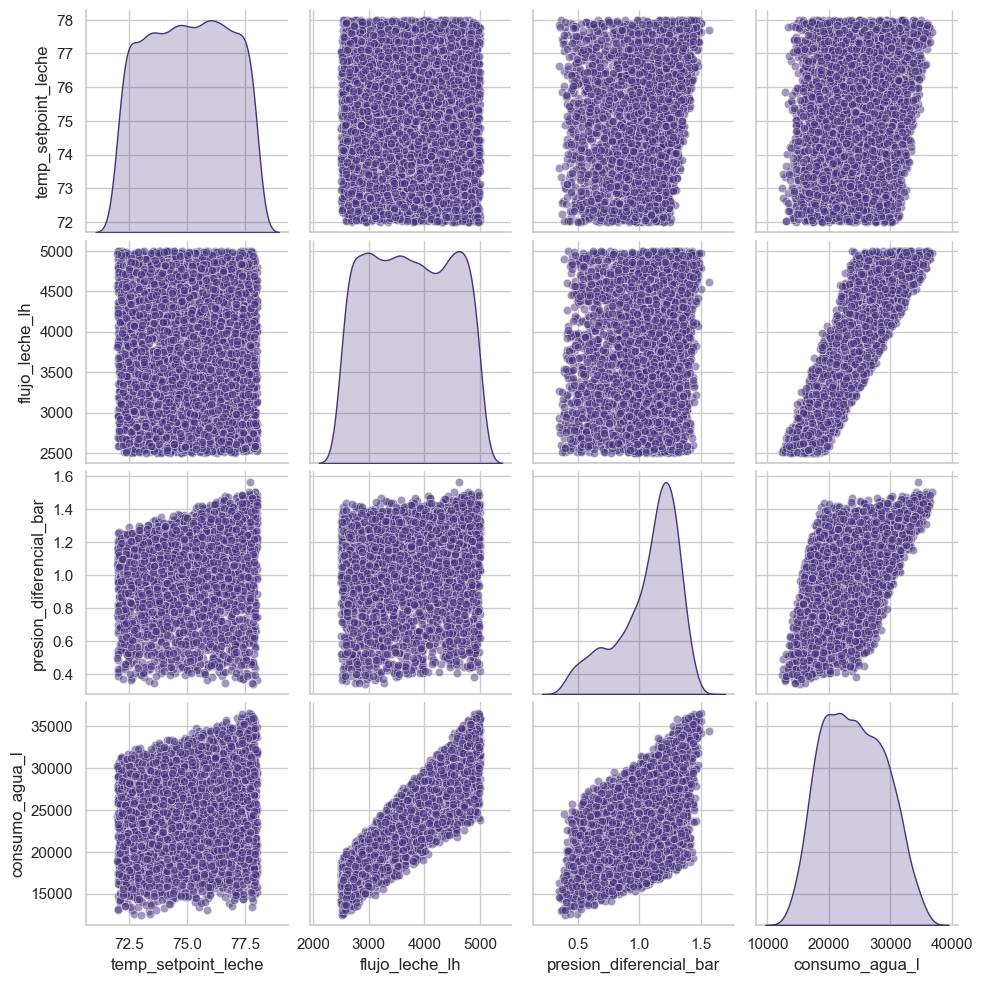

In [15]:
# Añade esto a tu EDA para ver la "cara" de la correlación
columnas_clave = ['temp_setpoint_leche', 'flujo_leche_lh', 'presion_diferencial_bar', 'consumo_agua_l']
sns.pairplot(df[columnas_clave], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.show()

#### 3. Validación de la Restricción de Seguridad (Trade-off de Pasteurización)

Conclusión para tu informe:
"La aparente falta de correlación lineal en el espacio global de seguridad se debe a la codependencia no lineal entre el flujo másico y la temperatura de mantenimiento. El modelo de Red Neuronal es indispensable en este escenario, ya que los métodos estadísticos simples no logran segmentar el hiperplano de seguridad alimentaria."

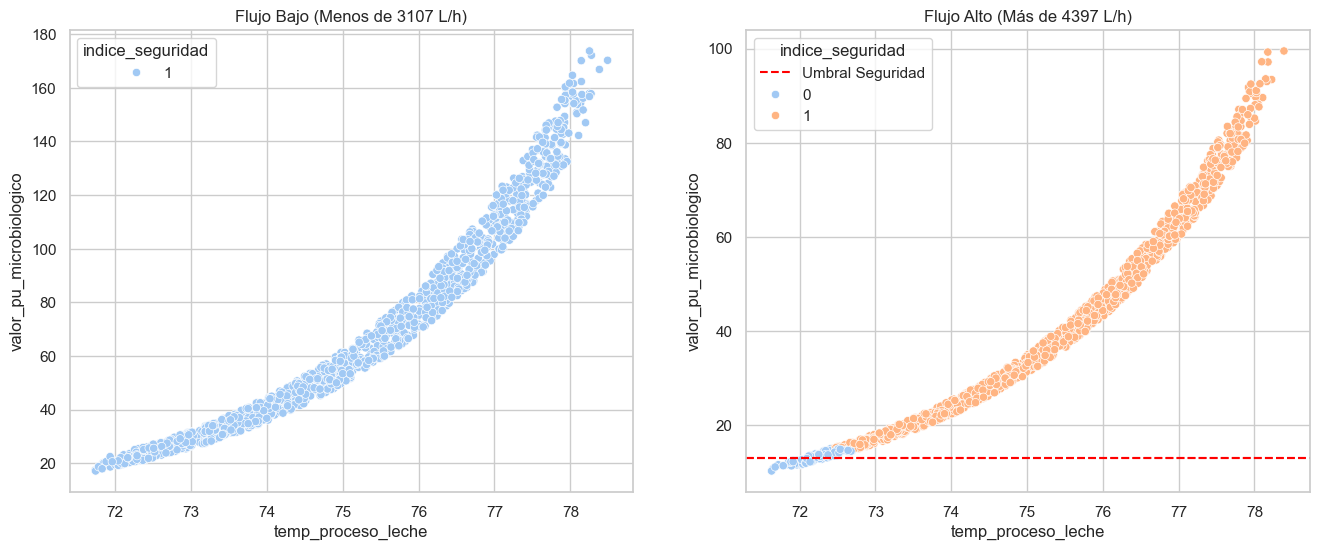

In [16]:
# Filtramos usando los percentiles 25 y 75 para asegurar que haya datos
bajo = df['flujo_leche_lh'].quantile(0.25)
alto = df['flujo_leche_lh'].quantile(0.75)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df[df['flujo_leche_lh'] <= bajo], x='temp_proceso_leche', y='valor_pu_microbiologico', 
                hue='indice_seguridad', palette='pastel', ax=ax1)
ax2.axhline(13, color='red', linestyle='--', label='Umbral Seguridad')
ax1.set_title(f'Flujo Bajo (Menos de {bajo:.0f} L/h)')

sns.scatterplot(data=df[df['flujo_leche_lh'] >= alto], x='temp_proceso_leche', y='valor_pu_microbiologico', 
                hue='indice_seguridad', palette='pastel', ax=ax2)
ax2.axhline(13, color='red', linestyle='--', label='Umbral Seguridad')
ax2.set_title(f'Flujo Alto (Más de {alto:.0f} L/h)')

plt.show()

#### 4. Análisis de Eficiencia Térmica: El "Efecto Abanico"
Esta gráfica es fundamental para justificar el ahorro del 20%. Queremos ver cómo el consumo_agua_l se dispara para un mismo temp_setpoint_leche a medida que el ensuciamiento (fouling) aumenta.

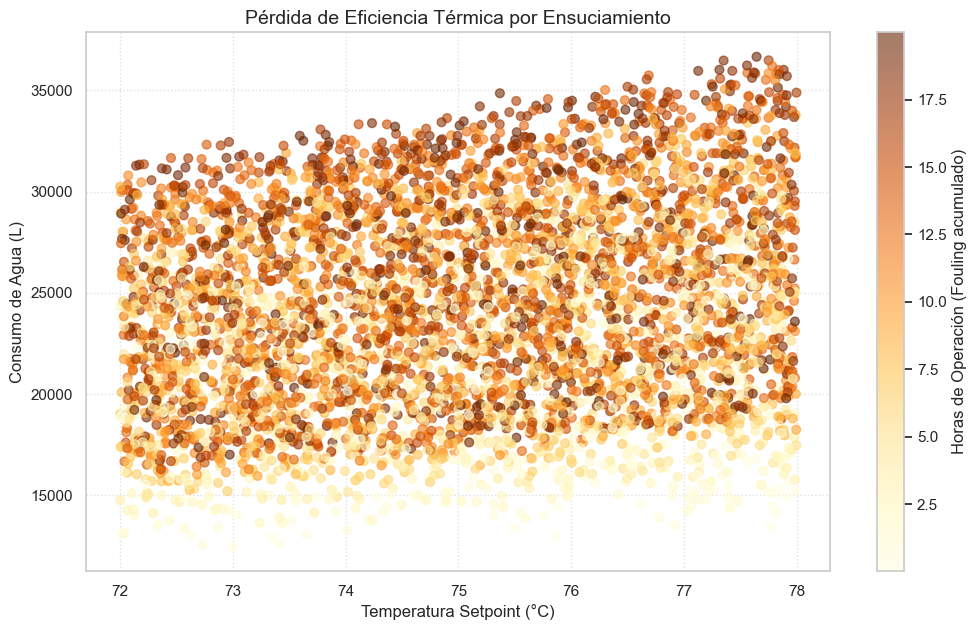

In [17]:
# Gráfica de Eficiencia: Setpoint vs Consumo coloreado por Horas desde Limpieza
plt.figure(figsize=(12, 7))

# Usamos un regplot para ver la tendencia lineal pero con los puntos coloreados
sc = plt.scatter(df['temp_setpoint_leche'], 
                 df['consumo_agua_l'], 
                 c=df['horas_desde_limpieza'], 
                 cmap='YlOrBr', 
                 alpha=0.6, 
                 s=40)

plt.colorbar(sc, label='Horas de Operación (Fouling acumulado)')
plt.title('Pérdida de Eficiencia Térmica por Ensuciamiento', fontsize=14)
plt.xlabel('Temperatura Setpoint (°C)', fontsize=12)
plt.ylabel('Consumo de Agua (L)', fontsize=12)

# Añadimos una nota de texto para el auditor
plt.annotate('Mayor consumo para el mismo setpoint\ndebido a la resistencia térmica del fouling', 
             xy=(82, df['consumo_agua_l'].max()*0.8), 
             fontsize=10, bbox=dict(boxstyle="round", fc="w", alpha=0.5))

plt.grid(True, linestyle=':', alpha=0.6)
plt.show()